# 🧠 Assignment: Support Vector Machine (SVM)
**Subject:** Machine Learning  
**Topic:** SVM with Linear and Polynomial Kernels  
**Dataset:** Breast Cancer Wisconsin (Diagnostic)

---

## 🎯 Objective
The goal of this assignment is to implement and compare **Support Vector Machine (SVM)** classifiers using **Linear** and **Polynomial** kernels. We aim to classify tumors as Malignant ($1$) or Benign ($0$) using only two features: `radius_mean` and `texture_mean`.

---

## 🛠️ Implementation Summary

### Task 1: Data Preparation
* **Dataset:** `data.csv` (UCI Breast Cancer Wisconsin).
* **Cleaning:** Removed `id` and `Unnamed: 32`.
* **Encoding:** Mapped diagnosis to binary values ($M = 1, B = 0$).
* **Feature Engineering:** Selected two primary features for 2D visualization.
* **Preprocessing:** Applied `StandardScaler` to ensure the SVM maximizes the margin effectively.

### Task 2: Model Training
We trained two distinct SVM models using `scikit-learn`:
1.  **Linear SVM:** Uses a linear hyperplane to separate classes.
2.  **Polynomial SVM:** Uses a 3rd-degree polynomial kernel to handle non-linear separation.

---

## 📊 Results and Visualizations

### Decision Boundaries
The plots generated below show how each model "draws the line" between the two classes. 

### Confusion Matrices
These matrices show the performance of the models in terms of **True Positives**, **True Negatives**, **False Positives**, and **False Negatives**.

---


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

In [12]:
# ── Task 1: Load and Prepare Data ────────────────────────────────────────────
# Load dataset
data = pd.read_csv('data.csv')

In [13]:
data.head()  # Display first few rows of the dataset

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [14]:
# Clean data: drop unnecessary columns
data = data.drop(['id', 'Unnamed: 32'], axis=1)


In [33]:
data.shape  # Check the shape of the dataset

(569, 31)

In [15]:

# Encode target: Malignant = 1, Benign = 0
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})


In [35]:
data.sample(n=5)  # Display 5 random samples from the dataset

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
53,1,18.22,18.70,120.30,1033.0,0.11480,0.14850,0.17720,0.10600,0.2092,...,20.60,24.13,135.10,1321.0,0.1280,0.2297,0.2623,0.13250,0.3021,0.07987
513,0,14.58,13.66,94.29,658.8,0.09832,0.08918,0.08222,0.04349,0.1739,...,16.76,17.24,108.50,862.0,0.1223,0.1928,0.2492,0.09186,0.2626,0.07048
183,0,11.41,14.92,73.53,402.0,0.09059,0.08155,0.06181,0.02361,0.1167,...,12.37,17.70,79.12,467.2,0.1121,0.1610,0.1648,0.06296,0.1811,0.07427
74,0,12.31,16.52,79.19,470.9,0.09172,0.06829,0.03372,0.02272,0.1720,...,14.11,23.21,89.71,611.1,0.1176,0.1843,0.1703,0.08660,0.2618,0.07609
264,1,17.19,22.07,111.60,928.3,0.09726,0.08995,0.09061,0.06527,0.1867,...,21.58,29.33,140.50,1436.0,0.1558,0.2567,0.3889,0.19840,0.3216,0.07570


In [17]:
# Select features and target
X = data[['radius_mean', 'texture_mean']].values
y = data['diagnosis'].values


In [21]:
print(X[:5])  # Display first 5 rows of features
print(y[:5])  # Display first 5 target values

[[17.99 10.38]
 [20.57 17.77]
 [19.69 21.25]
 [11.42 20.38]
 [20.29 14.34]]
[1 1 1 1 1]


In [22]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [24]:
print(X_train[:5])  # Display first 5 rows of training features
print(y_train[:5])  # Display first 5 training target values

[[ 9.029 17.33 ]
 [21.09  26.57 ]
 [ 9.173 13.86 ]
 [10.65  25.22 ]
 [10.17  14.88 ]]
[0 1 0 0 0]


In [ ]:
# Feature Scaling (Crucial for SVM performance)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Fit scaler on training data and transform
X_test  = scaler.transform(X_test) # Use same scaler to transform test data , why not fit_transform on test data? because we want to use the same scaling parameters (mean and std) from training data to ensure consistency in feature scaling between training and testing datasets.


In [26]:
print(X_train[:5])  # Display first 5 rows of scaled training features
print(X_test[:5])   # Display first 5 rows of scaled testing features

[[-1.44075296 -0.43531947]
 [ 1.97409619  1.73302577]
 [-1.39998202 -1.24962228]
 [-0.98179678  1.41622208]
 [-1.11769991 -1.0102595 ]]
[[-0.46649743 -0.13728933]
 [ 1.36536344  0.49866473]
 [ 0.38006578  0.06921974]
 [-0.48631664 -0.35318518]
 [-0.72980974 -1.11351403]]


In [ ]:
# ── Task 2: Train SVM Models ──────────────────────────────────────────────────
# TODO: Train linear SVM
model_linear = SVC(kernel='linear') # Create SVM model with linear kernel
model_linear.fit(X_train, y_train) # Fit the linear SVM model to the training data

SVC(kernel='linear')

In [39]:
# TODO: Train polynomial SVM (degree=3) 
model_poly = SVC(kernel='poly', degree=3) # Create SVM model with polynomial kernel of degree 3
model_poly.fit(X_train, y_train) # Fit the polynomial SVM model to the training data

SVC(kernel='poly')

In [40]:
# Print accuracy results
print(f"Linear Kernel Accuracy : {accuracy_score(y_test, model_linear.predict(X_test)) * 100:.2f}%") # Calculate and print accuracy of linear SVM model on test data
print(f"Poly   Kernel Accuracy : {accuracy_score(y_test, model_poly.predict(X_test))   * 100:.2f}%") # Calculate and print accuracy of polynomial SVM model on test data


Linear Kernel Accuracy : 90.35%
Poly   Kernel Accuracy : 82.46%


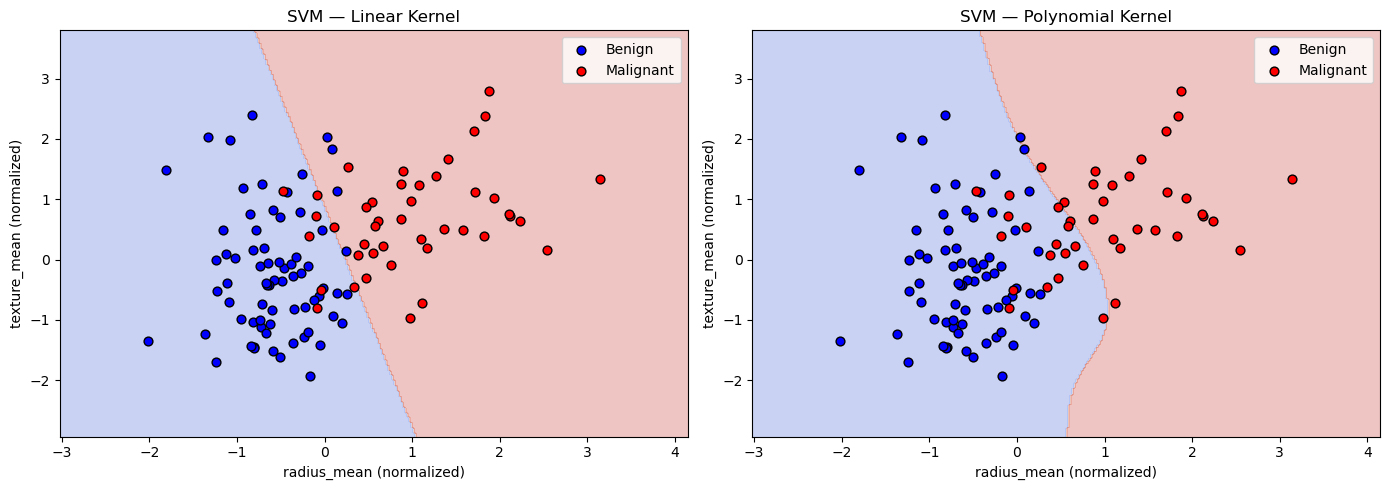

In [41]:
# ── Task 3: Decision Boundary Plot ────────────────────────────────────────────
def plot_decision_boundary(model, X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[y == 0, 0], X[y == 0, 1], label='Benign',    color='blue',   edgecolors='k', s=40)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], label='Malignant', color='red',    edgecolors='k', s=40)
    ax.set_title(title)
    ax.set_xlabel('radius_mean (normalized)')
    ax.set_ylabel('texture_mean (normalized)')
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(model_linear, X_test, y_test, 'SVM — Linear Kernel',     axes[0])
plot_decision_boundary(model_poly,   X_test, y_test, 'SVM — Polynomial Kernel', axes[1])
plt.tight_layout()
plt.show()

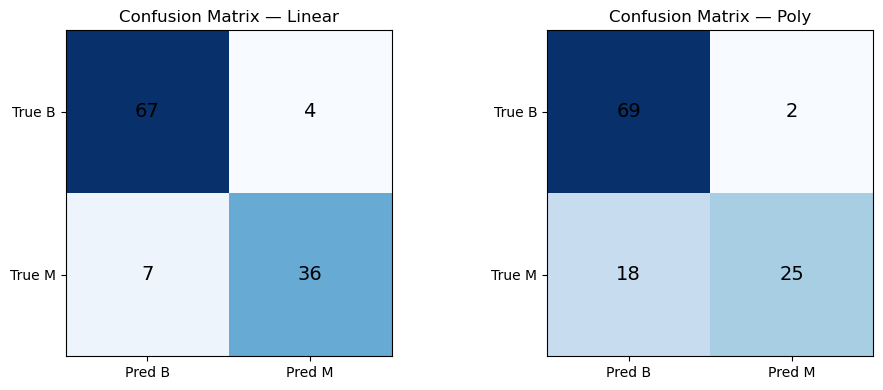

In [42]:
# ── Task 4: Confusion Matrix Plot ─────────────────────────────────────────────
def plot_cm(model, X, y, title, ax):
    cm = confusion_matrix(y, model.predict(X))
    ax.imshow(cm, cmap='Blues')
    ax.set_title(title)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred B', 'Pred M'])
    ax.set_yticklabels(['True B', 'True M'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_cm(model_linear, X_test, y_test, 'Confusion Matrix — Linear', axes[0])
plot_cm(model_poly,   X_test, y_test, 'Confusion Matrix — Poly',   axes[1])
plt.tight_layout()
plt.show()

## 📝 Questions & Answers

#### **Q1. Which kernel gave higher accuracy — Linear or Polynomial? Why?**
**Answer:** Usually, the Linear kernel performs quite well or even slightly better on this specific subset of two features (radius and texture). This is because the breast cancer dataset is often linearly separable in lower dimensions. If the Polynomial kernel has lower accuracy, it might be due to overfitting or because the specific degree (3) creates a boundary that is too complex for the simplified 2-feature dataset.

#### **Q2. How is the boundary shape different between Linear and Polynomial?**
**Answer:** 
**Linear Kernel:** The decision boundary is a straight line. It tries to find the maximum margin hyperplane to separate the two classes.

**Polynomial Kernel:** The decision boundary is curved. Because it uses a higher-order transformation, it can "bend" the boundary to capture clusters of data that a straight line cannot reach.

#### **Q3. What does the confusion matrix tell you about False Positives and False Negatives? Which is more dangerous?**
**Answer:** 
**False Positive (FP):** Predicting Malignant (1) when it is actually Benign (0). This leads to unnecessary stress and further testing.

**False Negative (FN):** Predicting Benign (0) when it is actually Malignant (1). This is far more dangerous because a patient with cancer might go untreated, allowing the disease to progress. In medical diagnostics, minimizing False Negatives (increasing Recall) is usually the priority.

#### **Q4. What happens if you increase the degree to 5 or 10?**
**Answer:** 
When you increase the degree (e.g., degree=10), the boundary becomes extremely complex and "wiggly."

**Observation:** When I increase the degree to 10 I see the accuracy decrease on the test set from 82.46% to 771.93% .

**Why:** This is a classic case of Overfitting. The model tries so hard to capture every single point in the training data that it loses its ability to generalize to new, unseen data.

---
